In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# import h5py
import glob

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import ringdown as rd

In [4]:
f_inj = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/injections/DS/220/DS_GW250114Kerr_dfpre0_dtaupre0_fmin10Hz_ppSNR20_H1.hdf5', key='H1')
fo_inj = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/injections/DS/220+221/DS_GW250114Kerr_dfpre0_dtaupre0_fmin10Hz_ppSNR20_H1.hdf5', key='H1')
ff_inj = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/injections/DS/220+210/DS_GW250114Kerr_dfpre0_dtaupre0_fmin10Hz_ppSNR20_H1.hdf5', key='H1')

In [19]:
ds_inj = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/DS/*/DS_GW250114Kerr_dfpre0_dtaupre0_fmin10Hz_ppSNR20_H1.hdf5')
ds_inj_v = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/DS/*/DS_GW250114Kerr_dtaupre0_fmin10Hz_ppSNR20_dfpre-0.5_H1.hdf5')

In [20]:
ds_dfs = {inj.split('/')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(ds_inj)}
ds_dfs_v = {inj.split('/')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(ds_inj_v)}

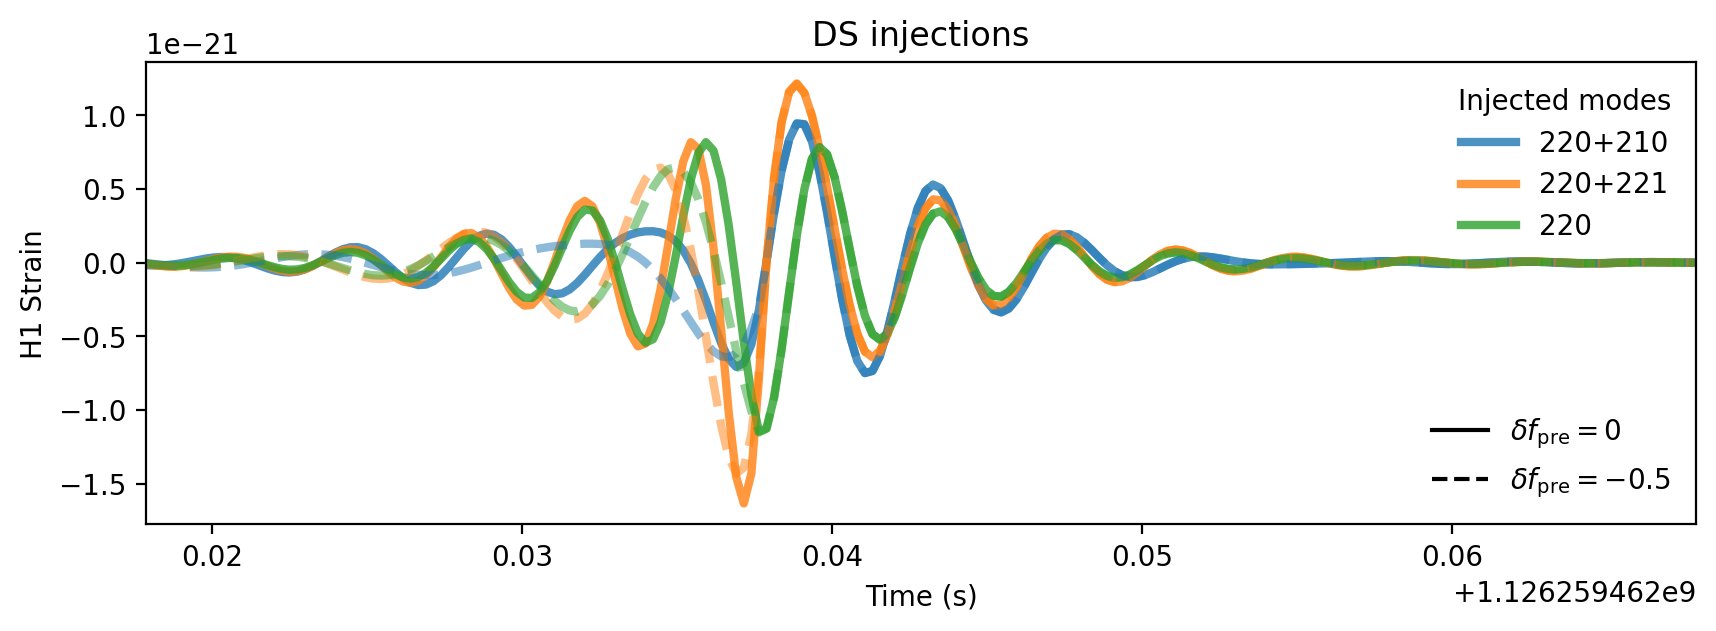

In [22]:
fig, ax = plt.subplots(figsize=(10, 3))
for i, (modes, df) in enumerate(ds_dfs.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.8, label=modes)
for i, (modes, df) in enumerate(ds_dfs_v.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.5, ls='--')

ax.set_xlim(np.median(df.index.values)-0.005, np.median(df.index.values)+0.045)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('DS injections')

leg1 = ax.legend(frameon=False, title='Injected modes')
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k'), 
                  plt.Line2D([], [], color='k', ls='--')], 
                 ['$\delta f_{\mathrm{pre}} = 0$',
                  '$\delta f_{\mathrm{pre}} = -0.5$'], 
                 frameon=False, loc='lower right')